# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

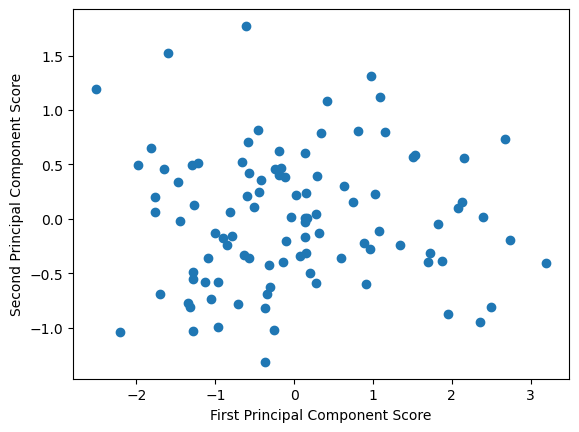

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### Answer to Number 2 :
 The three outliers in the upper-left corner have low first principal component scores, indicating they likely have low values for series_3, since the first PC is heavily weighted on series_3. They also have high second principal component scores, which suggests relatively high values for series_1 and series_2 compared to series_3, though it’s harder to separate their individual contributions because series_1 and series_2 are highly correlated by design. This PCA scatter plot effectively highlights clusters and anomalies but has limitations, as interpreting the PCs without the loadings is difficult, and relative relationships between variables can be obscured. A pairplot of all three series would better reveal their direct relationships and confirm that series_1 and series_2 are nearly linear, while variation in series_3 explains most of the observed spread.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

## Marketing Campaign Dataset - Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import os
import kagglehub

# Download and load the dataset
marketing_dataset_path = kagglehub.dataset_download("rodsaldanha/arketing-campaign")
marketing_dataset_path_to_file = os.path.join(marketing_dataset_path, "marketing_campaign.csv")

marketing_dataset_raw = pd.read_csv(marketing_dataset_path_to_file, sep=';')

# Check for missing values and drop them
marketing_dataset_cleaned = marketing_dataset_raw.dropna()

marketing_dataset_cleaned.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


C:\Users\jalva\AppData\Local\Temp\ipykernel_32384\3849272764.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  correlation_matrix = marketing_dataset_cleaned.corr()


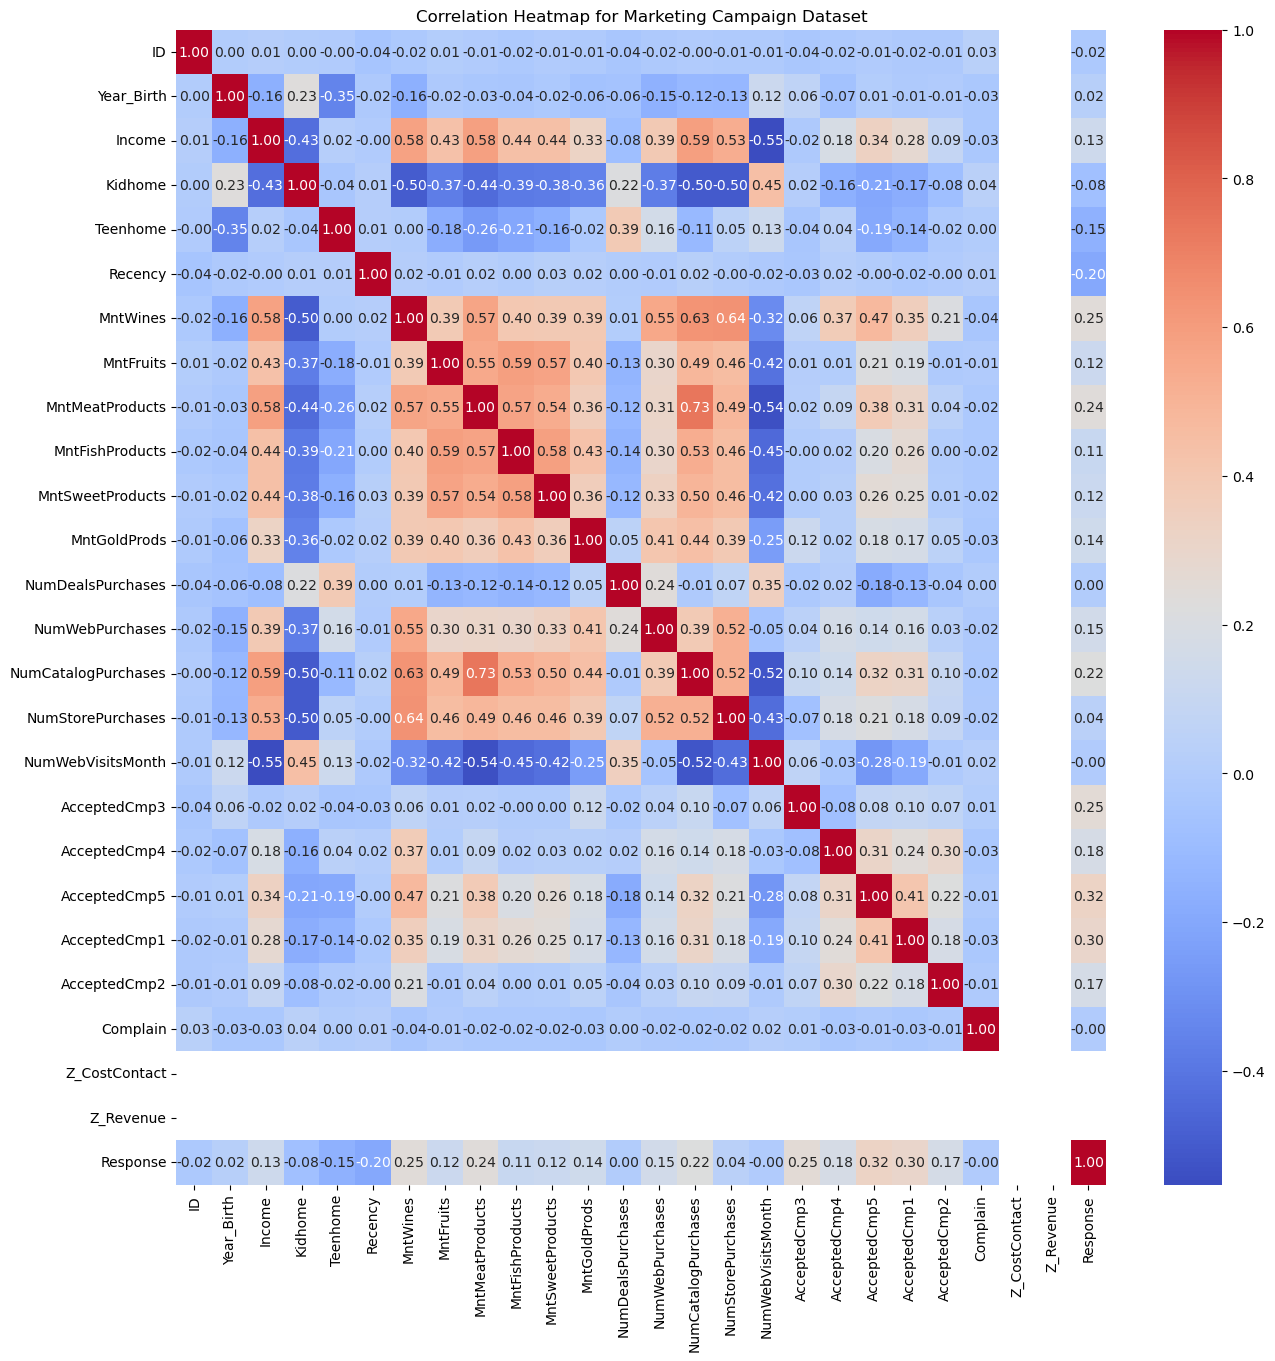

In [7]:
#correlation heatmap 
plt.figure(figsize=(15, 15))
correlation_matrix = marketing_dataset_cleaned.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap for Marketing Campaign Dataset")
plt.show()

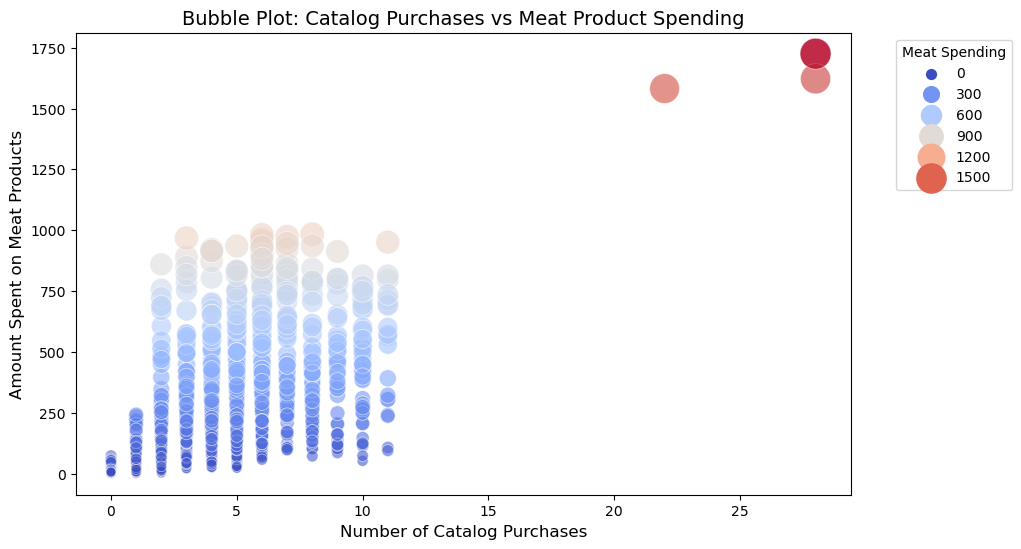

In [ ]:
#Bubble Plot: NumCatalogPurchases vs MntMeatProducts
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=marketing_dataset_cleaned,
    x='NumCatalogPurchases',           
    y='MntMeatProducts',               
    size='MntMeatProducts',            
    hue='MntMeatProducts',             
    sizes=(50, 500),                   
    palette='coolwarm',                
    alpha=0.6                         
)

plt.title('Bubble Plot: Catalog Purchases vs Meat Product Spending', fontsize=14)
plt.xlabel('Number of Catalog Purchases', fontsize=12)
plt.ylabel('Amount Spent on Meat Products', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Meat Spending')
plt.show()

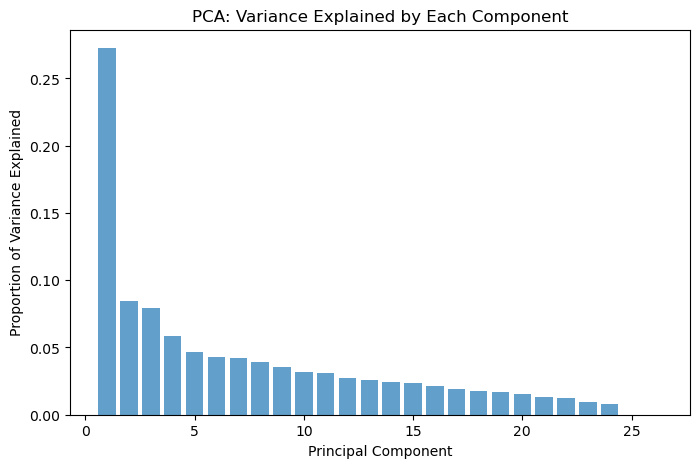

Variance captured by first PC: 27.26%
Variance captured by first two PCs: 35.73%


In [11]:
# Perform PCA
numerical_cols = marketing_dataset_cleaned.select_dtypes(include=['int64', 'float64']).columns
scaler = StandardScaler()
scaled_data = scaler.fit_transform(marketing_dataset_cleaned[numerical_cols])

pca = PCA()
pca_result = pca.fit_transform(scaled_data)

# Plot variance explained by each principal component
plt.figure(figsize=(8, 5))
explained_variance_ratio = pca.explained_variance_ratio_
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, alpha=0.7)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('PCA: Variance Explained by Each Component')
plt.show()

# Print cumulative variance explained by first principal component
print(f"Variance captured by first PC: {explained_variance_ratio[0]:.2%}")
print(f"Variance captured by first two PCs: {explained_variance_ratio[:2].sum():.2%}")


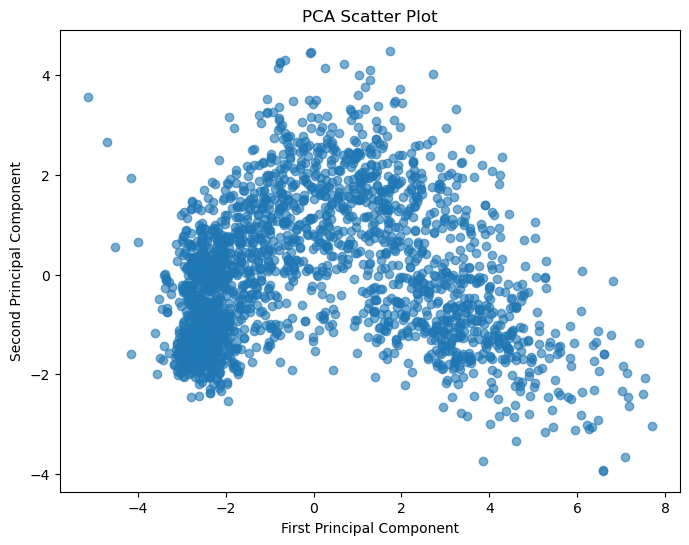

In [12]:
# Scatter plot of first two PCA components
plt.figure(figsize=(8, 6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6)
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.title("PCA Scatter Plot")
plt.show()


In [13]:
# Linear Regression: Predicting Income based on selected features
features = ['Year_Birth', 'MntWines', 'MntFruits', 'MntMeatProducts']
X = marketing_dataset_cleaned[features]
y = marketing_dataset_cleaned['Income']

lr = LinearRegression()
lr.fit(X, y)

print("Linear Regression Coefficients:")
for feature, coef in zip(features, lr.coef_):
    print(f"{feature}: {coef:.2f}")

print(f"Intercept: {lr.intercept_:.2f}")


Linear Regression Coefficients:
Year_Birth: -201.54
MntWines: 24.64
MntFruits: 77.49
MntMeatProducts: 36.64
Intercept: 433369.13


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

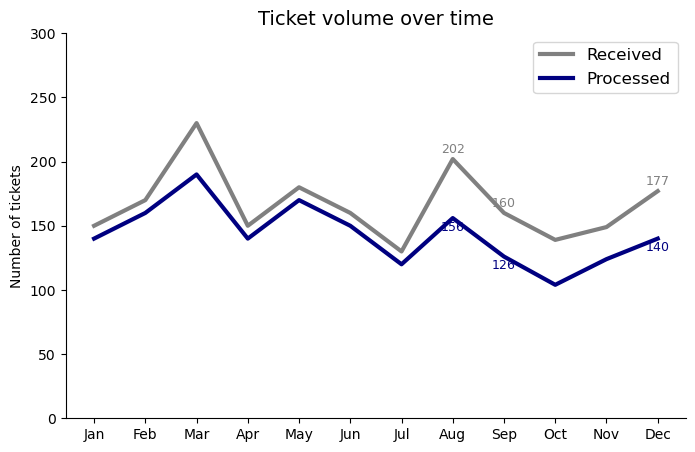

In [2]:
#figure 5.9 from the book
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
received = [150, 170, 230, 150, 180, 160, 130, 202, 160, 139, 149, 177]
processed = [140, 160, 190, 140, 170, 150, 120, 156, 126, 104, 124, 140]


plt.figure(figsize=(8, 5))
plt.plot(months, received, color='gray', linewidth=3, label='Received')
plt.plot(months, processed, color='navy', linewidth=3, label='Processed')

for i, (r, p) in enumerate(zip(received, processed)):
    if i in [7, 8, 11]:  # Annotate Aug, Sep, Dec only
        plt.text(months[i], r + 5, str(r), color='gray', ha='center', fontsize=9)
        plt.text(months[i], p - 10, str(p), color='navy', ha='center', fontsize=9)

plt.title('Ticket volume over time', fontsize=14)
plt.ylabel('Number of tickets')
plt.ylim(0, 300)
plt.legend(loc='upper right', fontsize=12)

for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.show()
